# pNN — Channel-Parameterized (1ℓ2τ + 2ℓ2τ, Combined Run2+Run3)

A single flat-feature MLP trained on BOTH channels at once, with a
`channel` indicator (0 = 1ℓ2τ, 1 = 2ℓ2τ) fed in as an extra input feature -
the network parameter, in the same sense a resonance-mass pNN takes the
mass hypothesis as an input rather than training one model per mass point.
Same `SimpleMLP`/`train_model` architecture and conventions as
`DNN.ipynb`/`DNN_2l2tau.ipynb`.

**Feature set caveat - read this first.** 1ℓ2τ and 2ℓ2τ do not share the
same branches (different lepton count, jets not guaranteed in 2ℓ2τ, and
each channel has its own hand-engineered pairwise variables like `m_l1l2`
or `SumPt_l1j1j2` that only make sense in one channel). This notebook
restricts to the **intersection** of each channel's own leakage-free
Combined (Run2+Run3) feature set - likely a noticeably smaller, more
generic set (basic kinematics: `tau1_pt`, `tau2_pt`, `met_met`, `n_jet`,
etc.) than either channel's standalone DNN sees. The exact count prints
below once both channels are loaded - inspect it before reading too much
into any AUC comparison against the single-channel DNNs, which had far
more features to work with.

**Data.** Combined Run2+Run3 per channel (built the same way as each
channel's own Combined track), then the two channels are concatenated with
the `channel` tag, stratified split on `label` + `channel` + `run` jointly
so every split keeps the same channel/run mix.

## Libraries

In [1]:
import os

os.environ["PYTHONHASHSEED"] = "42"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import uproot
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

RANDOM_STATE = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def set_seed(seed: int = RANDOM_STATE):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)


#set_seed(RANDOM_STATE)
print(f"Using device: {DEVICE}")

Using device: cuda


## Paths / Preselections / Leakage Policy

Both channels preselections and BLOCK_EXACT sets, unioned so the same
is_feature policy is safely conservative for either channel's branches
(blocking a branch the other channel doesn't have is harmless - it just
never appears as a candidate).

In [2]:
BASE_DIR_RUN2_1L2T = Path("PPSSP_2026/1l2tau/run2")
BASE_DIR_RUN3_1L2T = Path("PPSSP_2026/1l2tau/run3")
BASE_DIR_RUN2_2L2T = Path("PPSSP_2026/2l2tau/run2")
BASE_DIR_RUN3_2L2T = Path("PPSSP_2026/2l2tau/run3")

TREE_NAME = "AnalysisMiniTree"

PRESELECTION_1L2T = "(n_b_jet == 0) & (n_jet >= 2)"
PRESELECTION_2L2T = "(n_b_jet == 0) & (l1_charge * l2_charge < 0) & (mZ_cut > 0)"

FILES = {
    "signal_ggF": ("signal_ggF.root", 1),
    "signal_VBF": ("signal_VBF.root", 1),
    "Diboson":    ("diboson.root",    0),
    "Zjets":      ("Zjets.root",      0),
    "Wjets":      ("Wjets.root",      0),
    "ttbar":      ("ttbar.root",      0),
    "tops":       ("tops.root",       0),
    "SingleH":    ("singleH.root",    0),
    "Vgamma":     ("Vgamma.root",     0),
    "VVV":        ("VVV.root",        0),
}

WEIGHT_PARTS = ["weight", "weights"]

BLOCK_SUBSTR = ["weight", "effsf", "_ff", "truth", "istrue", "fake", "anti",
                "dsid", "eventnumber", "_RNNTight", "_isOS", "_d0sig"]

# Union of DNN.ipynb (1l2tau) and DNN_2l2tau.ipynb (2l2tau) BLOCK_EXACT.
BLOCK_EXACT = {
    "n_b_jet", "pass1l2tau", "pass2l2tau", "hhml_subchannelflavor",
    "tau1_RNNJetScoreSigTrans", "tau2_RNNJetScoreSigTrans",
    "pair_isOStaus", "pair_isOSleptau", "pair_isOSlep1lep2",
    "tau2_baseline_RNNTight", "l1_d0sig", "tau1_charge", "tau2_charge", "mZ_veto",
    "tau1_decayMode", "tau2_decayMode", "tau1_nprong", "tau2_nprong",
    "mZ_cut", "mZreq",
}

BLOCK_EXACT_LOWER = {b.lower() for b in BLOCK_EXACT}


def is_feature(branch: str) -> bool:
    lb = branch.lower()
    return lb not in BLOCK_EXACT_LOWER and not any(s.lower() in lb for s in BLOCK_SUBSTR)

## Data Loading Helpers

In [3]:
def discover_common_features(base_dir, files=FILES, tree_name=TREE_NAME):
    common = None
    for fname, _ in files.values():
        keys = set(uproot.open({str(Path(base_dir) / fname): tree_name}).keys())
        common = keys if common is None else common & keys
    features = sorted(b for b in common if is_feature(b))
    print(f"{len(features)} candidate features (common to all {len(files)} processes, leakage-free)")
    return features


def load_run_data(base_dir, features, preselection, files=FILES, weight_parts=WEIGHT_PARTS,
                   tree_name=TREE_NAME, verbose=True):
    base_dir = Path(base_dir)
    dfs = []
    for proc, (fname, label) in files.items():
        tree = uproot.open({str(base_dir / fname): tree_name})
        df = tree.arrays(features + weight_parts, cut=preselection, library="pd")
        df["w_phys"] = df["weights"] * df["weight"]
        df["label"] = label
        df["process"] = proc
        dfs.append(df)
        if verbose:
            print(f"{proc:12s}: {len(df):>8d} events after preselection")
    return pd.concat(dfs, ignore_index=True)


def clean_data(data, features, verbose=True):
    data = data.copy()
    nun = data[features].nunique()
    const = nun[nun <= 1].index.tolist()
    features = [f for f in features if f not in const]
    data = data.drop(columns=const)
    if verbose:
        print(f"Dropped {len(const)} constant/empty features:\n  {sorted(const)}")
    for f in features:
        m = data[f] < -100
        if m.any():
            if verbose:
                print(f"  sentinel -> NaN: {f} ({m.mean():.1%})")
            data[f] = data[f].mask(m)
    if verbose:
        print(f"\n{len(features)} final features")
        print(f"Total: {len(data)} events | signal = {(data.label==1).sum()} | "
              f"background = {(data.label==0).sum()}")
    return data, features

## Load 1ℓ2τ (Run 2 + Run 3 -> Combined)

Same logic as `DNN.ipynb`'s Combined track: load each run separately,
clean, then concatenate on the intersection of the two runs' feature sets
with a `run` tag.

In [4]:
candidate_features_run2_1l2t = discover_common_features(BASE_DIR_RUN2_1L2T)
data_run2_1l2t = load_run_data(BASE_DIR_RUN2_1L2T, candidate_features_run2_1l2t, PRESELECTION_1L2T)
data_run2_1l2t, features_run2_1l2t = clean_data(data_run2_1l2t, candidate_features_run2_1l2t)

candidate_features_run3_1l2t = discover_common_features(BASE_DIR_RUN3_1L2T)
data_run3_1l2t = load_run_data(BASE_DIR_RUN3_1L2T, candidate_features_run3_1l2t, PRESELECTION_1L2T)
data_run3_1l2t, features_run3_1l2t = clean_data(data_run3_1l2t, candidate_features_run3_1l2t)

candidate_features_comb_1l2t = sorted(set(features_run2_1l2t) & set(features_run3_1l2t))
keep_cols_1l2t = candidate_features_comb_1l2t + ["w_phys", "label", "process"]

d2 = data_run2_1l2t[keep_cols_1l2t].copy(); d2["run"] = 2
d3 = data_run3_1l2t[keep_cols_1l2t].copy(); d3["run"] = 3

data_comb_1l2t, features_comb_1l2t = clean_data(
    pd.concat([d2, d3], ignore_index=True), candidate_features_comb_1l2t,
)

print(f"\n1l2tau Combined: {len(data_comb_1l2t)} events, {len(features_comb_1l2t)} features")

81 candidate features (common to all 10 processes, leakage-free)
signal_ggF  :    67075 events after preselection
signal_VBF  :    21639 events after preselection
Diboson     :   312600 events after preselection
Zjets       :   141863 events after preselection
Wjets       :    31272 events after preselection
ttbar       :     7335 events after preselection
tops        :    62238 events after preselection
SingleH     :    11124 events after preselection
Vgamma      :    21510 events after preselection
VVV         :    14028 events after preselection
Dropped 17 constant/empty features:
  ['SumPt_l1j1j2', 'SumPt_t1t2l1', 'dR_j1j2_l1', 'dR_j1j2_t1', 'dR_j1j2_t2', 'm_jjl1', 'm_jjl1t1', 'm_jjt1', 'n_lep', 'n_tau', 'pass_DLT', 'tau1_base_id', 'tau1_besline_RNNMedium_eleid', 'tau1_passOR', 'tau2_base_id', 'tau2_besline_RNNMedium_eleid', 'tau2_passOR']

64 final features
Total: 690684 events | signal = 88714 | background = 601970
81 candidate features (common to all 10 processes, leakage-free)


## Load 2ℓ2τ (Run 2 + Run 3 -> Combined)

Same logic, using `PRESELECTION_2L2T`.

In [5]:
candidate_features_run2_2l2t = discover_common_features(BASE_DIR_RUN2_2L2T)
data_run2_2l2t = load_run_data(BASE_DIR_RUN2_2L2T, candidate_features_run2_2l2t, PRESELECTION_2L2T)
data_run2_2l2t, features_run2_2l2t = clean_data(data_run2_2l2t, candidate_features_run2_2l2t)

candidate_features_run3_2l2t = discover_common_features(BASE_DIR_RUN3_2L2T)
data_run3_2l2t = load_run_data(BASE_DIR_RUN3_2L2T, candidate_features_run3_2l2t, PRESELECTION_2L2T)
data_run3_2l2t, features_run3_2l2t = clean_data(data_run3_2l2t, candidate_features_run3_2l2t)

candidate_features_comb_2l2t = sorted(set(features_run2_2l2t) & set(features_run3_2l2t))
keep_cols_2l2t = candidate_features_comb_2l2t + ["w_phys", "label", "process"]

d2 = data_run2_2l2t[keep_cols_2l2t].copy(); d2["run"] = 2
d3 = data_run3_2l2t[keep_cols_2l2t].copy(); d3["run"] = 3

data_comb_2l2t, features_comb_2l2t = clean_data(
    pd.concat([d2, d3], ignore_index=True), candidate_features_comb_2l2t,
)

print(f"\n2l2tau Combined: {len(data_comb_2l2t)} events, {len(features_comb_2l2t)} features")

87 candidate features (common to all 10 processes, leakage-free)
signal_ggF  :    31959 events after preselection
signal_VBF  :     5598 events after preselection
Diboson     :    36877 events after preselection
Zjets       :     7746 events after preselection
Wjets       :       67 events after preselection
ttbar       :      331 events after preselection
tops        :     3832 events after preselection
SingleH     :     2946 events after preselection
Vgamma      :     2019 events after preselection
VVV         :     3593 events after preselection
Dropped 7 constant/empty features:
  ['dR_j1j2_l1', 'dR_j1j2_t1', 'dR_j1j2_t2', 'n_lep', 'tau1_base_id', 'tau2_base_id', 'xgb_score']

80 final features
Total: 94968 events | signal = 37557 | background = 57411
87 candidate features (common to all 10 processes, leakage-free)
signal_ggF  :    96909 events after preselection
signal_VBF  :     3439 events after preselection
Diboson     :    82336 events after preselection
Zjets       :    12919

## Merge Channels

Restrict to the intersection of `features_comb_1l2t` and
`features_comb_2l2t`, tag each channel (`channel` = 0 for 1ℓ2τ, 1 for
2ℓ2τ), concatenate. Check the printed feature count against each channel's
own count below - a large drop confirms the caveat at the top of this
notebook.

In [6]:
candidate_features_pnn = sorted(set(features_comb_1l2t) & set(features_comb_2l2t))
keep_cols_pnn = candidate_features_pnn + ["w_phys", "label", "process", "run"]

d_1l2t = data_comb_1l2t[keep_cols_pnn].copy(); d_1l2t["channel"] = 0
d_2l2t = data_comb_2l2t[keep_cols_pnn].copy(); d_2l2t["channel"] = 1

data_pnn, features_pnn = clean_data(
    pd.concat([d_1l2t, d_2l2t], ignore_index=True), candidate_features_pnn,
)

print(f"\npNN merged: {len(data_pnn)} events, {len(features_pnn)} shared features "
      f"(1l2tau alone had {len(features_comb_1l2t)}, 2l2tau alone had {len(features_comb_2l2t)})")

for ch, name in ((0, "1l2tau"), (1, "2l2tau")):
    sub = data_pnn[data_pnn["channel"] == ch]
    print(f"  channel={ch} ({name}): {len(sub)} events | "
          f"signal yield = {sub.loc[sub.label==1,'w_phys'].sum():.2f} | "
          f"background yield = {sub.loc[sub.label==0,'w_phys'].sum():.2f}")

Dropped 0 constant/empty features:
  []

61 final features
Total: 2340086 events | signal = 431669 | background = 1908417

pNN merged: 2340086 events, 61 shared features (1l2tau alone had 64, 2l2tau alone had 80)
  channel=0 (1l2tau): 2015576 events | signal yield = 3.91 | background yield = 30834.21
  channel=1 (2l2tau): 324510 events | signal yield = 0.91 | background yield = 3160.25


## Train/Validation/Test Split

Deterministic 80/10/10 split, stratified on `label` + `channel` + `run`
jointly (a combined strata column), so every split keeps the same
channel/run mix.

In [7]:
def make_fit_weights(labels, abs_weights):
    labels = np.asarray(labels)
    fit_weights = np.asarray(abs_weights, dtype=float).copy()
    sum_signal = fit_weights[labels == 1].sum()
    sum_background = fit_weights[labels == 0].sum()
    fit_weights[labels == 1] *= sum_background / sum_signal
    fit_weights *= len(fit_weights) / fit_weights.sum()
    return fit_weights


def make_3way_split(data, test_size=0.10, val_size=0.10, seed=RANDOM_STATE, strata_col=None):
    strata = data[strata_col] if strata_col is not None else data["label"]
    trainval_df, test_df = train_test_split(data, test_size=test_size, random_state=seed, stratify=strata)

    val_frac_of_remaining = val_size / (1 - test_size)
    strata_tv = trainval_df[strata_col] if strata_col is not None else trainval_df["label"]
    train_df, val_df = train_test_split(trainval_df, test_size=val_frac_of_remaining, random_state=seed, stratify=strata_tv)

    for name, df in (("Train", train_df), ("Val", val_df), ("Test", test_df)):
        sig_n, bkg_n = int((df.label == 1).sum()), int((df.label == 0).sum())
        sig_y = df.loc[df.label == 1, "w_phys"].sum()
        bkg_y = df.loc[df.label == 0, "w_phys"].sum()
        print(f"{name:5s}: {len(df):>8d} events | signal = {sig_n:>7d} (yield={sig_y:>10.2f}) | "
              f"background = {bkg_n:>7d} (yield={bkg_y:>10.2f}) | "
              f"signal weight scale factor = {bkg_y / sig_y:.1f}")

    return train_df, val_df, test_df


data_pnn["strata"] = (
    data_pnn["label"].astype(str) + "_" + data_pnn["channel"].astype(str) + "_" + data_pnn["run"].astype(str)
)

train_df, val_df, test_df = make_3way_split(data_pnn, strata_col="strata")

Train:  1872068 events | signal =  345334 (yield=      3.85) | background = 1526734 (yield=  27475.01) | signal weight scale factor = 7133.2
Val  :   234009 events | signal =   43168 (yield=      0.48) | background =  190841 (yield=   3266.00) | signal weight scale factor = 6789.6
Test :   234009 events | signal =   43167 (yield=      0.48) | background =  190842 (yield=   3253.45) | signal weight scale factor = 6768.1


## Imputation, Scaling, Missingness Flags, Channel Feature

Median imputation + standard scaling fit on TRAIN only (same convention as
`DNN.ipynb`), `__isnan` missingness flags for anything with train-set
missing values, and the `channel` indicator concatenated on **unscaled**
(it's the pNN's parameter input, 0/1, not a physical quantity to
standardize).

In [8]:
X_train_raw, y_train, w_train = train_df[features_pnn], train_df["label"].to_numpy(), train_df["w_phys"].to_numpy()
X_val_raw,   y_val,   w_val   = val_df[features_pnn],   val_df["label"].to_numpy(),   val_df["w_phys"].to_numpy()
X_test_raw,  y_test,  w_test  = test_df[features_pnn],  test_df["label"].to_numpy(),  test_df["w_phys"].to_numpy()

nan_train = X_train_raw.isna()
flag_cols = nan_train.columns[nan_train.any()].tolist()


def make_flags(X_raw):
    f = X_raw[flag_cols].isna().astype(np.float32)
    f.columns = [f"{c}__isnan" for c in flag_cols]
    return f


train_medians = X_train_raw.median()
X_train_imp = X_train_raw.fillna(train_medians)
X_val_imp = X_val_raw.fillna(train_medians)
X_test_imp = X_test_raw.fillna(train_medians)

scaler = StandardScaler()
X_train_phys = scaler.fit_transform(X_train_imp)
X_val_phys = scaler.transform(X_val_imp)
X_test_phys = scaler.transform(X_test_imp)

channel_train = train_df[["channel"]].to_numpy(dtype=np.float32)
channel_val = val_df[["channel"]].to_numpy(dtype=np.float32)
channel_test = test_df[["channel"]].to_numpy(dtype=np.float32)

X_train_scaled = np.hstack([X_train_phys, make_flags(X_train_raw).to_numpy(), channel_train])
X_val_scaled = np.hstack([X_val_phys, make_flags(X_val_raw).to_numpy(), channel_val])
X_test_scaled = np.hstack([X_test_phys, make_flags(X_test_raw).to_numpy(), channel_test])

INPUT_COLUMNS = features_pnn + [f"{c}__isnan" for c in flag_cols] + ["channel"]

assert np.isfinite(X_train_scaled).all(), "NaN/inf reached the model input (train)"
assert np.isfinite(X_val_scaled).all(), "NaN/inf reached the model input (val)"
assert np.isfinite(X_test_scaled).all(), "NaN/inf reached the model input (test)"

print(f"{len(flag_cols)} features had missing values in train -> added {len(flag_cols)} __isnan flags")
print(f"Final input width = {X_train_scaled.shape[1]} "
      f"= {len(features_pnn)} features + {len(flag_cols)} flags + 1 channel indicator")

23 features had missing values in train -> added 23 __isnan flags
Final input width = 85 = 61 features + 23 flags + 1 channel indicator


## PyTorch Dataset & Model

Identical `SimpleMLP` architecture to `DNN.ipynb`/`DNN_2l2tau.ipynb` - the
`channel` column is just one more input dimension, no architectural
change needed for a pNN (that's the point of the parameterization: one
network, one extra input, not two networks).

In [9]:
BATCH_SIZE = 8192
DEFAULT_HIDDEN_SIZES = (256, 256, 128, 128, 64, 32)

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32, device=DEVICE)
y_train_t = torch.tensor(y_train, dtype=torch.float32, device=DEVICE)
w_train_fit = make_fit_weights(y_train, np.abs(w_train))
w_train_t = torch.tensor(w_train_fit, dtype=torch.float32, device=DEVICE)
w_train_abs_t = torch.tensor(np.abs(w_train), dtype=torch.float32, device=DEVICE)

X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32, device=DEVICE)
y_val_t = torch.tensor(y_val, dtype=torch.float32, device=DEVICE)
w_val_t = torch.tensor(np.abs(w_val), dtype=torch.float32, device=DEVICE)

X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32, device=DEVICE)
y_test_t = torch.tensor(y_test, dtype=torch.float32, device=DEVICE)
w_test_t = torch.tensor(np.abs(w_test), dtype=torch.float32, device=DEVICE)


class SimpleMLP(nn.Module):
    def __init__(self, n_features, hidden_sizes=DEFAULT_HIDDEN_SIZES, dropout=0.3):
        super().__init__()
        layers = []
        in_size = n_features
        for hidden_size in hidden_sizes:
            layers += [nn.Linear(in_size, hidden_size), nn.ReLU(), nn.Dropout(dropout)]
            in_size = hidden_size
        layers.append(nn.Linear(in_size, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


def build_model(hidden_sizes=DEFAULT_HIDDEN_SIZES, dropout=0.3, n_features=None):
    if n_features is None:
        n_features = X_train_scaled.shape[1]
    return SimpleMLP(n_features=n_features, hidden_sizes=hidden_sizes, dropout=dropout).to(DEVICE)


model = build_model()
print(model)

SimpleMLP(
  (net): Sequential(
    (0): Linear(in_features=85, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=128, out_features=128, bias=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=128, out_features=64, bias=True)
    (13): ReLU()
    (14): Dropout(p=0.3, inplace=False)
    (15): Linear(in_features=64, out_features=32, bias=True)
    (16): ReLU()
    (17): Dropout(p=0.3, inplace=False)
    (18): Linear(in_features=32, out_features=1, bias=True)
  )
)


## Training Loop

Weighted BCE, Adam, early stopping on weighted validation AUC - identical
convention to `DNN.ipynb`.

In [10]:
N_EPOCHS = 50
PATIENCE = 10
LEARNING_RATE = 1e-3


def run_epoch(model, X, y, w, criterion, optimizer, train, batch_size=BATCH_SIZE):
    model.train(train)
    n = X.shape[0]
    order = torch.randperm(n, device=DEVICE) if train else torch.arange(n, device=DEVICE)

    total_loss = torch.zeros((), device=DEVICE)
    total_weight = torch.zeros((), device=DEVICE)
    all_labels, all_probs, all_weights = [], [], []

    with torch.set_grad_enabled(train):
        for start in range(0, n, batch_size):
            idx = order[start:start + batch_size]
            xb, yb, wb = X[idx], y[idx], w[idx]

            logits = model(xb)
            loss = (criterion(logits, yb) * wb).sum() / wb.sum()

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.detach() * wb.sum()
            total_weight += wb.sum()
            all_labels.append(yb.detach())
            all_probs.append(torch.sigmoid(logits).detach())
            all_weights.append(wb.detach())

    labels = torch.cat(all_labels).cpu().numpy()
    probs = torch.cat(all_probs).cpu().numpy()
    weights = torch.cat(all_weights).cpu().numpy()
    auc = roc_auc_score(labels, probs, sample_weight=weights)

    return (total_loss / total_weight).item(), auc


def train_model(hidden_sizes=DEFAULT_HIDDEN_SIZES, dropout=0.3, lr=LEARNING_RATE,
                 n_epochs=N_EPOCHS, patience=PATIENCE, verbose=True,
                 X_train_data=None, y_train_data=None, w_train_data=None, w_train_eval_data=None,
                 X_val_data=None, y_val_data=None, w_val_data=None):

    X_train_data = X_train_t if X_train_data is None else X_train_data
    y_train_data = y_train_t if y_train_data is None else y_train_data
    w_train_data = w_train_t if w_train_data is None else w_train_data
    w_train_eval_data = w_train_abs_t if w_train_eval_data is None else w_train_eval_data
    X_val_data = X_val_t if X_val_data is None else X_val_data
    y_val_data = y_val_t if y_val_data is None else y_val_data
    w_val_data = w_val_t if w_val_data is None else w_val_data

    trial_model = build_model(hidden_sizes=hidden_sizes, dropout=dropout, n_features=X_train_data.shape[1])
    criterion = nn.BCEWithLogitsLoss(reduction="none")
    optimizer = torch.optim.Adam(trial_model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "train_auc": [], "val_auc": [],
               "train_loss_eval": [], "train_auc_eval": []}
    best_val_auc, best_train_auc, best_train_auc_eval = -np.inf, None, None
    best_state, epochs_no_improve = None, 0

    for epoch in range(1, n_epochs + 1):
        train_loss, train_auc = run_epoch(trial_model, X_train_data, y_train_data, w_train_data, criterion, optimizer, train=True)
        train_loss_eval, train_auc_eval = run_epoch(trial_model, X_train_data, y_train_data, w_train_eval_data, criterion, optimizer, train=False)
        val_loss, val_auc = run_epoch(trial_model, X_val_data, y_val_data, w_val_data, criterion, optimizer, train=False)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_auc"].append(train_auc)
        history["val_auc"].append(val_auc)
        history["train_loss_eval"].append(train_loss_eval)
        history["train_auc_eval"].append(train_auc_eval)

        if verbose:
            print(f"Epoch {epoch:3d} | train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
                  f"| train_auc={train_auc:.4f} train_auc_eval={train_auc_eval:.4f} val_auc={val_auc:.4f}")

        if val_auc > best_val_auc:
            best_val_auc, best_train_auc, best_train_auc_eval = val_auc, train_auc, train_auc_eval
            best_state, epochs_no_improve = {k: v.clone() for k, v in trial_model.state_dict().items()}, 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch} (best val_auc={best_val_auc:.4f})")
                break

    trial_model.load_state_dict(best_state)
    return trial_model, history, best_val_auc, best_train_auc, best_train_auc_eval


model, history, best_val_auc, best_train_auc, best_train_auc_eval = train_model()

print(f"\nBest val_auc = {best_val_auc:.4f} | train_auc (dropout on) = {best_train_auc:.4f} "
      f"| train_auc_eval (dropout off, comparable) = {best_train_auc_eval:.4f}")

Epoch   1 | train_loss=0.4346 val_loss=0.3464 | train_auc=0.8910 train_auc_eval=0.9276 val_auc=0.9262
Epoch   2 | train_loss=0.3615 val_loss=0.2882 | train_auc=0.9209 train_auc_eval=0.9333 val_auc=0.9301
Epoch   3 | train_loss=0.3476 val_loss=0.3257 | train_auc=0.9266 train_auc_eval=0.9369 val_auc=0.9324
Epoch   4 | train_loss=0.3402 val_loss=0.3132 | train_auc=0.9296 train_auc_eval=0.9390 val_auc=0.9336
Epoch   5 | train_loss=0.3363 val_loss=0.2910 | train_auc=0.9313 train_auc_eval=0.9409 val_auc=0.9353
Epoch   6 | train_loss=0.3283 val_loss=0.3115 | train_auc=0.9345 train_auc_eval=0.9424 val_auc=0.9361
Epoch   7 | train_loss=0.3263 val_loss=0.3087 | train_auc=0.9354 train_auc_eval=0.9437 val_auc=0.9371
Epoch   8 | train_loss=0.3280 val_loss=0.3028 | train_auc=0.9346 train_auc_eval=0.9439 val_auc=0.9370
Epoch   9 | train_loss=0.3228 val_loss=0.3385 | train_auc=0.9367 train_auc_eval=0.9446 val_auc=0.9377
Epoch  10 | train_loss=0.3193 val_loss=0.3209 | train_auc=0.9382 train_auc_eval=0.

## Evaluation

Overall weighted val AUC, plus a per-channel breakdown - the diagnostic
that actually matters for a pNN: is the shared network doing well on both
channels, or is one channel dragging/boosting the pooled number?

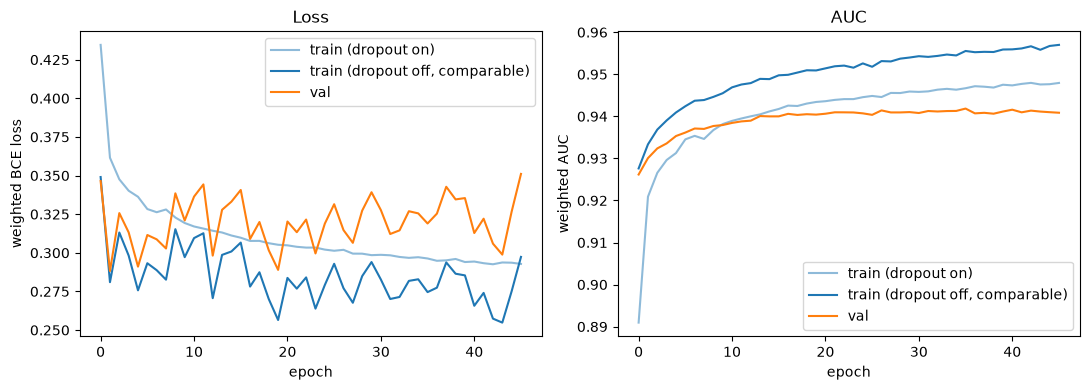

Overall weighted val AUC (both channels pooled) = 0.9418
  channel=0 (1l2tau) val AUC = 0.9363  (n=201558)
  channel=1 (2l2tau) val AUC = 0.9629  (n=32451)


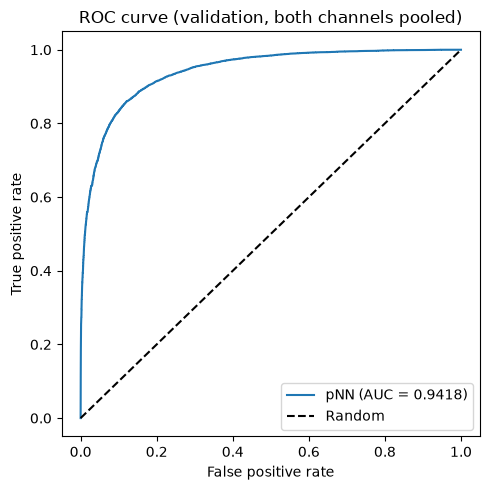

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history["train_loss"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[0].plot(history["train_loss_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[0].plot(history["val_loss"], label="val", color="tab:orange")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("weighted BCE loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history["train_auc"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[1].plot(history["train_auc_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[1].plot(history["val_auc"], label="val", color="tab:orange")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("weighted AUC")
axes[1].set_title("AUC")
axes[1].legend()

plt.tight_layout()
plt.show()

model.eval()
with torch.no_grad():
    val_probs = torch.sigmoid(model(X_val_t)).cpu().numpy()

auc_val = roc_auc_score(y_val, val_probs, sample_weight=np.abs(w_val))
print(f"Overall weighted val AUC (both channels pooled) = {auc_val:.4f}")

val_channel = val_df["channel"].to_numpy()
for ch, name in ((0, "1l2tau"), (1, "2l2tau")):
    m = val_channel == ch
    auc_ch = roc_auc_score(y_val[m], val_probs[m], sample_weight=np.abs(w_val[m]))
    print(f"  channel={ch} ({name}) val AUC = {auc_ch:.4f}  (n={m.sum()})")

fpr, tpr, _ = roc_curve(y_val, val_probs, sample_weight=np.abs(w_val))
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"pNN (AUC = {auc_val:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve (validation, both channels pooled)")
plt.legend()
plt.tight_layout()
plt.show()

## Feature Importance (Permutation)

Same technique as `DNN.ipynb`. `channel` is included as a ranked column -
its AUC drop when shuffled tells you how much the network actually relies
on knowing which channel an event came from, versus learning something
channel-agnostic from the shared kinematics.

Baseline weighted AUC: 0.9418


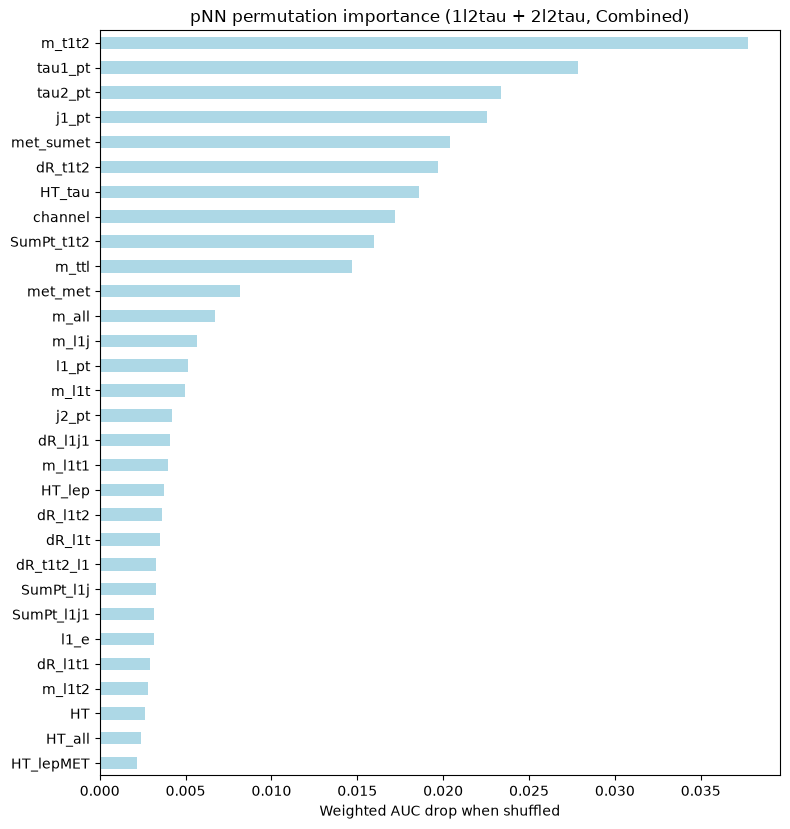


'channel' rank: 8 of 85


m_t1t2        0.037729
tau1_pt       0.027864
tau2_pt       0.023384
j1_pt         0.022544
met_sumet     0.020388
dR_t1t2       0.019708
HT_tau        0.018604
channel       0.017189
SumPt_t1t2    0.015991
m_ttl         0.014720
met_met       0.008189
m_all         0.006694
m_l1j         0.005655
l1_pt         0.005145
m_l1t         0.004961
Name: auc_drop, dtype: float64

In [12]:
def permutation_importance(model, X, y, w, columns, n_repeats=5, random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    model.eval()

    y_np = y.cpu().numpy()
    w_np = w.cpu().numpy()

    with torch.no_grad():
        baseline_probs = torch.sigmoid(model(X)).cpu().numpy()
    baseline_auc = roc_auc_score(y_np, baseline_probs, sample_weight=w_np)
    print(f"Baseline weighted AUC: {baseline_auc:.4f}")

    mean_drops = []
    for i, feat in enumerate(columns):
        drops = []
        for _ in range(n_repeats):
            perm = torch.as_tensor(rng.permutation(X.shape[0]), device=X.device)
            X_perm = X.clone()
            X_perm[:, i] = X_perm[perm, i]
            with torch.no_grad():
                probs = torch.sigmoid(model(X_perm)).cpu().numpy()
            auc = roc_auc_score(y_np, probs, sample_weight=w_np)
            drops.append(baseline_auc - auc)
        mean_drops.append(np.mean(drops))

    return pd.Series(mean_drops, index=columns, name="auc_drop").sort_values(ascending=False)


def plot_importance_bar(imp, top_n=30, title="", color="lightblue"):
    n = min(top_n, len(imp))
    fig, ax = plt.subplots(figsize=(8, max(4, 0.28 * n)))
    imp.head(top_n)[::-1].plot.barh(ax=ax, color=color)
    ax.set_xlabel("Weighted AUC drop when shuffled")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


importance = permutation_importance(model, X_val_t, y_val_t, w_val_t, INPUT_COLUMNS, n_repeats=5)
plot_importance_bar(importance, top_n=30, title="pNN permutation importance (1l2tau + 2l2tau, Combined)")
print(f"\n'channel' rank: {list(importance.index).index('channel') + 1} of {len(importance)}")
importance.head(15)

## Physics Figure of Merit & Held-Out Test Evaluation

Same max-Asimov-significance scan as `DNN.ipynb`, on the pooled val/test
sets. Score cut selected on VAL only, applied frozen to TEST.

In [13]:
def significance_scan(y_true, scores, w_phys, n_thr=200, min_bkg=1.0):
    thr = np.quantile(scores, np.linspace(0, 1, n_thr))
    best_z, best_t = 0.0, None
    for t in thr:
        sel = scores >= t
        S = w_phys[sel & (y_true == 1)].sum()
        B = w_phys[sel & (y_true == 0)].sum()
        if S <= 0 or B < min_bkg:
            continue
        z = np.sqrt(2 * ((S + B) * np.log(1 + S / B) - S))
        if z > best_z:
            best_z, best_t = z, t
    return best_z, best_t


w_val_signed = val_df["w_phys"].to_numpy()
z_val, thr_val = significance_scan(y_val, val_probs, w_val_signed)

print(f"Weighted val AUC = {auc_val:.4f}")
print(f"Max Asimov Z (val, pooled) = {z_val:.3f} at score cut = {thr_val:.4f}")

# ---- HELD-OUT TEST EVALUATION - scored EXACTLY ONCE ------------------------
model.eval()
with torch.no_grad():
    test_probs = torch.sigmoid(model(X_test_t)).cpu().numpy()

w_test_signed = test_df["w_phys"].to_numpy()
auc_test = roc_auc_score(y_test, test_probs, sample_weight=np.abs(w_test))

S_test = w_test_signed[(test_probs >= thr_val) & (y_test == 1)].sum()
B_test = w_test_signed[(test_probs >= thr_val) & (y_test == 0)].sum()
z_test = (np.sqrt(2 * ((S_test + B_test) * np.log(1 + S_test / B_test) - S_test))
          if (S_test > 0 and B_test > 0) else np.nan)

print(f"\nWeighted AUC: val = {auc_val:.4f}  |  test (held-out, scored once) = {auc_test:.4f}")
print(f"At the VAL-selected score cut = {thr_val:.4f} (frozen, NOT re-scanned on test):")
print(f"  test S = {S_test:.2f} | test B = {B_test:.2f} | test Z = {z_test:.3f}  (val Z was {z_val:.3f})")

test_channel = test_df["channel"].to_numpy()
for ch, name in ((0, "1l2tau"), (1, "2l2tau")):
    m = test_channel == ch
    auc_ch = roc_auc_score(y_test[m], test_probs[m], sample_weight=np.abs(w_test[m]))
    print(f"  channel={ch} ({name}) test AUC = {auc_ch:.4f}  (n={m.sum()})")

Weighted val AUC = 0.9418
Max Asimov Z (val, pooled) = 0.056 at score cut = 0.9945

Weighted AUC: val = 0.9418  |  test (held-out, scored once) = 0.9461
At the VAL-selected score cut = 0.9945 (frozen, NOT re-scanned on test):
  test S = 0.08 | test B = 1.23 | test Z = 0.068  (val Z was 0.056)
  channel=0 (1l2tau) test AUC = 0.9405  (n=201557)
  channel=1 (2l2tau) test AUC = 0.9668  (n=32452)


## Sanity Checks & Summary

In [14]:
set_seed(RANDOM_STATE)
_, _, det_check_a, _, _ = train_model(hidden_sizes=(64,), n_epochs=5, patience=5, verbose=False)

set_seed(RANDOM_STATE)
_, _, det_check_b, _, _ = train_model(hidden_sizes=(64,), n_epochs=5, patience=5, verbose=False)
assert det_check_a == det_check_b, f"Determinism check FAILED: {det_check_a} != {det_check_b}"

print(f"Determinism check passed: two re-seeded runs give identical val_auc = {det_check_a:.6f}")

summary = pd.DataFrame([{
    "model": f"pNN (channel-parameterized, {len(INPUT_COLUMNS)} inputs)",
    "val_auc": auc_val,
    "max_asimov_Z (val)": z_val,
    "test_auc (held-out, scored once)": auc_test,
    "test_Z_at_val_cut (held-out)": z_test,
}])

print("\nFinal summary (pNN, 1l2tau + 2l2tau, Combined Run2+Run3):")
print(summary.to_string(index=False))
summary

Determinism check passed: two re-seeded runs give identical val_auc = 0.927440

Final summary (pNN, 1l2tau + 2l2tau, Combined Run2+Run3):
                                 model  val_auc  max_asimov_Z (val)  test_auc (held-out, scored once)  test_Z_at_val_cut (held-out)
pNN (channel-parameterized, 85 inputs) 0.941847            0.055898                          0.946051                      0.067822


,model,val_auc,max_asimov_Z (val),"test_auc (held-out, scored once)",test_Z_at_val_cut (held-out)
0,"pNN (channel-parameterized, 85 inputs)",0.941847,0.055898,0.946051,0.067822
